Gaining an understanding of how the google mediapipe model api works

In [90]:
import pickle
import pandas as pd

with open("1_hand.pkl","rb") as of: # this pickle file is a serialization of the result of the mediapipe model 
                                    # (RECOGNIZER.recognize_for_video(mp_img, frame_timestamp_ms))
    result = pickle.load(of)

landmarks_list = result.hand_landmarks
hand = result.handedness

In [91]:
hand

[[Category(index=0, score=0.9787698984146118, display_name='Right', category_name='Right')]]

In [92]:
landmarks_list

[[NormalizedLandmark(x=0.4782683849334717, y=0.8171038627624512, z=6.080036314415338e-07, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.5373613834381104, y=0.791435718536377, z=-0.027842886745929718, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.5890774726867676, y=0.7507827281951904, z=-0.048690032213926315, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.6380817294120789, y=0.7289295792579651, z=-0.06930606812238693, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.6831026673316956, y=0.7228916883468628, z=-0.09064734727144241, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.5545569658279419, y=0.6126064658164978, z=-0.029407527297735214, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.5841180086135864, y=0.5404629707336426, z=-0.05460241064429283, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.6035126447677612, y=0.49739140272140503, z=-0.07503489404916763, visibility=0.0, presence=0.0),
  NormalizedLandmark(x=0.62060266733

In [93]:
print(landmarks_list[0][0].x)
print(landmarks_list[0][0].y)
print(landmarks_list[0][0].z)
print(landmarks_list[0][0].visibility)
print(landmarks_list[0][0].presence)

0.4782683849334717
0.8171038627624512
6.080036314415338e-07
0.0
0.0


In [94]:
landmarks = landmarks_list[0]
df = pd.DataFrame(data=dict(x=[l.x for l in landmarks],
                            y=[l.y for l in landmarks],
                            z=[l.z for l in landmarks],
                            visibility=[l.visibility for l in landmarks],
                            presence=[l.presence for l in landmarks],
                            ))

In [95]:
df

,x,y,z,visibility,presence
0,0.478268,0.817104,6.080036e-07,0.0,0.0
1,0.537361,0.791436,-2.784289e-02,0.0,0.0
2,0.589077,0.750783,-4.869003e-02,0.0,0.0
3,0.638082,0.728930,-6.930607e-02,0.0,0.0
4,0.683103,0.722892,-9.064735e-02,0.0,0.0
5,0.554557,0.612606,-2.940753e-02,0.0,0.0
6,0.584118,0.540463,-5.460241e-02,0.0,0.0
7,0.603513,0.497391,-7.503489e-02,0.0,0.0
8,0.620603,0.457445,-8.990920e-02,0.0,0.0
9,0.520926,0.597891,-3.431681e-02,0.0,0.0


# Considerations for training the gesture recognition model

## Features

- each hand-rig consists of 21 points
- ```visibility``` and ```presence``` seem to always be 0 $\rarr$ omit these features
- train on a 5 / 10s time series of positions (21 3d-points each) $\rarr$ label complete time series

## Handedness

- _Mirror_ all points of a left hand in the data pipeline $\rarr$ make all training data _right_ hands
    - Problem: gestures get mirrores too; e.g ppinting to left gets pointig to right, but has the wrong label
- Duplicate number of gestures and introduce a _left_ and _right_ version
    - Problem: double the training data & time needed

---

Get adjancency matrix

In [96]:
from mediapipe.framework.formats import landmark_pb2
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_dim = (500,600,3)
img = np.ones(img_dim,dtype=np.uint8)*255

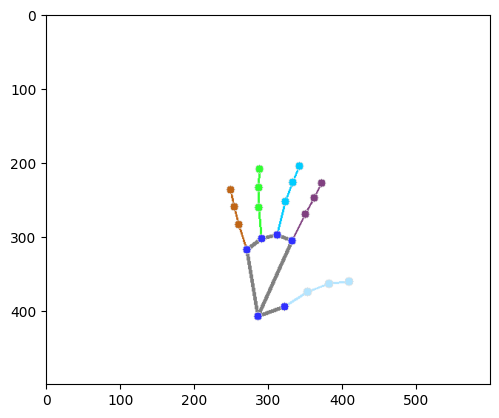

In [97]:
img_mp = img.copy()

hand_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
hand_landmarks_proto.landmark.extend(
    [
        landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z)
        for landmark in landmarks
    ]
)
mp.solutions.drawing_utils.draw_landmarks(
    img_mp,
    hand_landmarks_proto,
    mp.solutions.hands.HAND_CONNECTIONS,
    mp.solutions.drawing_styles.get_default_hand_landmarks_style(),
    mp.solutions.drawing_styles.get_default_hand_connections_style(),
)

plt.imshow(img_mp)

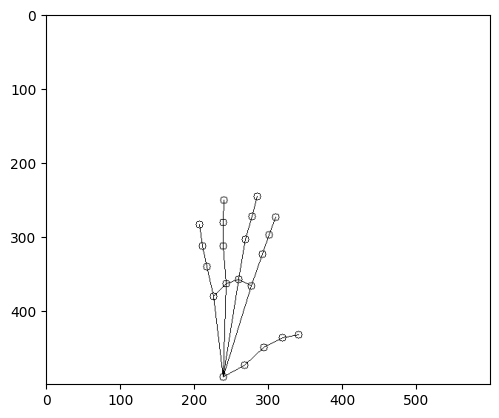

In [ ]:
adjacency = [
             (0,1),(0,5),(0,9),(0,13),(0,17),(5,9),(9,13),(13,17), # palm
             (1,2),(2,3),(3,4), #thumb
             (5,6),(6,7),(7,8), #index finger
             (9,10),(10,11),(11,12), #middle finger
             (13,14),(14,15),(15,16), #ring finger
             (17,18),(18,19),(19,20) #pinky
             ]

img_np = img.copy()

landmarks_tuples = [(int(a.x*img_dim[0]),int(a.y*img_dim[1])) for a in landmarks]

for x,y in landmarks_tuples:
    cv2.circle(img_np,(x,y),5,0)

for a,b in adjacency:
    cv2.line(img_np,landmarks_tuples[a],landmarks_tuples[b],0)

plt.imshow(img_np)
